# Regression Track

## Linear Regression

In [2]:
%%capture
%run regression_preprocessing.ipynb

In [3]:
#Imports

import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.decomposition import TruncatedSVD

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Common function for evaluating every regression model

def evaluate_regression_model(model, X_test_data, y_test_data):
    predictions = model.predict(X_test_data)

    r2 = r2_score(y_test_data, predictions)
    rmse = np.sqrt(mean_squared_error(y_test_data, predictions))
    mae = mean_absolute_error(y_test_data, predictions)

    return r2, rmse, mae, predictions

regression_results = []
model_registry = {}  # name -> dict(estimator, X_train, X_test, predictions)

## Linear Regression

In [5]:
# Linear Regression - Baseline

linear_model = LinearRegression()

linear_model.fit(X_train_encoded, y_train)

linear_r2, linear_rmse, linear_mae, linear_predictions = evaluate_regression_model(
    linear_model,
    X_test_encoded,
    y_test
)

print("Linear Regression — Baseline")
print(f"R²   : {linear_r2:.4f}")
print(f"RMSE : {linear_rmse:.4f}")
print(f"MAE  : {linear_mae:.4f}")

# Save baseline results
linear_baseline_r2 = linear_r2
linear_baseline_rmse = linear_rmse
linear_baseline_mae = linear_mae


Linear Regression — Baseline
R²   : 0.4909
RMSE : 13.0386
MAE  : 7.4728


In [6]:
# Linear Regression - Coefficients

linear_coefficients = pd.DataFrame({
    'Feature': all_feature_cols,
    'Coefficient': linear_model.coef_
}).sort_values(
    by='Coefficient',
    key=np.abs,
    ascending=False
)

print("Linear Regression Coefficients:")
display(linear_coefficients)


Linear Regression Coefficients:


,Feature,Coefficient
104,categorical__Facility Name_Coler-Goldwater Spe...,68.109860
103,categorical__Facility Name_Coler-Goldwater Spe...,60.495723
85,categorical__Facility Name_Blythedale Children...,33.903700
969,categorical__APR DRG Code_581,-33.035828
917,categorical__APR DRG Code_440,-32.016262
...,...,...
118,categorical__Facility Name_Ellis Hospital - Be...,0.011707
86,categorical__Facility Name_Bon Secours Communi...,-0.010179
943,categorical__APR DRG Code_510,-0.009255
499,categorical__CCS Diagnosis Code_227.0,-0.006681


In [7]:
# Adding Linear Regression to regression results

regression_results.append({
    'Model': 'Linear Regression',
    'R²': linear_baseline_r2,
    'RMSE': linear_baseline_rmse,
    'MAE': linear_baseline_mae
})

model_registry['Linear Regression'] = {
    'estimator': linear_model,
    'X_train': X_train_encoded,
    'X_test': X_test_encoded,
    'predictions': linear_predictions
}


## Ridge Regression

In [8]:
# Ridge Regression - Baseline

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_encoded, y_train)

ridge_r2, ridge_rmse, ridge_mae, ridge_predictions = evaluate_regression_model(
    ridge_model,
    X_test_encoded,
    y_test
)

print("Ridge Regression — Baseline")
print(f"R²   : {ridge_r2:.4f}")
print(f"RMSE : {ridge_rmse:.4f}")
print(f"MAE  : {ridge_mae:.4f}")

# Save baseline results
ridge_baseline_r2 = ridge_r2
ridge_baseline_rmse = ridge_rmse
ridge_baseline_mae = ridge_mae


Ridge Regression — Baseline
R²   : 0.4927
RMSE : 13.0152
MAE  : 7.4590


In [9]:
# Ridge Regression - Coefficients

ridge_coefficients = pd.DataFrame({
    'Feature': all_feature_cols,
    'Coefficient': ridge_model.coef_
}).sort_values(
    by='Coefficient',
    key=np.abs,
    ascending=False
)

print("Ridge Regression Coefficients:")
display(ridge_coefficients)


Ridge Regression Coefficients:


,Feature,Coefficient
104,categorical__Facility Name_Coler-Goldwater Spe...,65.872138
103,categorical__Facility Name_Coler-Goldwater Spe...,59.204775
85,categorical__Facility Name_Blythedale Children...,32.666773
902,categorical__APR DRG Code_4,31.514462
969,categorical__APR DRG Code_581,-28.376254
...,...,...
263,categorical__Facility Name_United Health Servi...,0.015258
118,categorical__Facility Name_Ellis Hospital - Be...,0.001964
486,categorical__CCS Diagnosis Code_210.0,-0.001332
854,categorical__APR DRG Code_26,-0.000844


In [10]:
# Adding Ridge Regression to regression results

regression_results.append({
    'Model': 'Ridge Regression',
    'R²': ridge_baseline_r2,
    'RMSE': ridge_baseline_rmse,
    'MAE': ridge_baseline_mae
})

model_registry['Ridge Regression'] = {
    'estimator': ridge_model,
    'X_train': X_train_encoded,
    'X_test': X_test_encoded,
    'predictions': ridge_predictions
}


## Lasso Regression

In [11]:
# Lasso Regression - Baseline

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train_encoded, y_train)

lasso_r2, lasso_rmse, lasso_mae, lasso_predictions = evaluate_regression_model(
    lasso_model,
    X_test_encoded,
    y_test
)

print("Lasso Regression — Baseline")
print(f"R²   : {lasso_r2:.4f}")
print(f"RMSE : {lasso_rmse:.4f}")
print(f"MAE  : {lasso_mae:.4f}")

# Save baseline results
lasso_baseline_r2 = lasso_r2
lasso_baseline_rmse = lasso_rmse
lasso_baseline_mae = lasso_mae


Lasso Regression — Baseline
R²   : 0.3885
RMSE : 14.2898
MAE  : 8.3527


In [12]:
# Lasso Regression - Coefficients

lasso_coefficients = pd.DataFrame({
    'Feature': all_feature_cols,
    'Coefficient': lasso_model.coef_
}).sort_values(
    by='Coefficient',
    key=np.abs,
    ascending=False
)

print("Lasso Regression Coefficients:")
display(lasso_coefficients)

print(f"\nNon-zero coefficients: {np.count_nonzero(lasso_model.coef_)} / {len(lasso_model.coef_)}")


Lasso Regression Coefficients:


,Feature,Coefficient
902,categorical__APR DRG Code_4,15.757934
1066,categorical__APR MDC Code_19,15.186784
990,categorical__APR DRG Code_640,-14.362845
710,categorical__CCS Procedure Code_34.0,11.851323
1011,categorical__APR DRG Code_750,7.490426
...,...,...
401,categorical__CCS Diagnosis Code_122.0,-0.000000
402,categorical__CCS Diagnosis Code_123.0,0.000000
403,categorical__CCS Diagnosis Code_124.0,-0.000000
404,categorical__CCS Diagnosis Code_125.0,-0.000000



Non-zero coefficients: 36 / 1160


In [13]:
# Adding Lasso Regression to regression results

regression_results.append({
    'Model': 'Lasso Regression',
    'R²': lasso_baseline_r2,
    'RMSE': lasso_baseline_rmse,
    'MAE': lasso_baseline_mae
})

model_registry['Lasso Regression'] = {
    'estimator': lasso_model,
    'X_train': X_train_encoded,
    'X_test': X_test_encoded,
    'predictions': lasso_predictions
}


## ElasticNet Regression

In [14]:
# ElasticNet Regression - Baseline

elastic_model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    max_iter=10000
)

elastic_model.fit(X_train_encoded, y_train)

elastic_r2, elastic_rmse, elastic_mae, elastic_predictions = evaluate_regression_model(
    elastic_model,
    X_test_encoded,
    y_test
)

print("ElasticNet Regression — Baseline")
print(f"R²   : {elastic_r2:.4f}")
print(f"RMSE : {elastic_rmse:.4f}")
print(f"MAE  : {elastic_mae:.4f}")

# Save baseline results
elastic_baseline_r2 = elastic_r2
elastic_baseline_rmse = elastic_rmse
elastic_baseline_mae = elastic_mae


ElasticNet Regression — Baseline
R²   : 0.3524
RMSE : 14.7057
MAE  : 8.6722


In [15]:
# ElasticNet - Coefficients

elastic_coefficients = pd.DataFrame({
    'Feature': all_feature_cols,
    'Coefficient': elastic_model.coef_
}).sort_values(
    by='Coefficient',
    key=np.abs,
    ascending=False
)

print("ElasticNet Regression Coefficients:")
display(elastic_coefficients)


ElasticNet Regression Coefficients:


,Feature,Coefficient
1066,categorical__APR MDC Code_19,8.534882
569,categorical__CCS Diagnosis Code_659.0,5.207377
5,numeric__APR Severity of Illness Code,5.074875
1011,categorical__APR DRG Code_750,4.812740
990,categorical__APR DRG Code_640,-4.375025
...,...,...
453,categorical__CCS Diagnosis Code_175.0,-0.000000
454,categorical__CCS Diagnosis Code_177.0,-0.000000
455,categorical__CCS Diagnosis Code_178.0,-0.000000
456,categorical__CCS Diagnosis Code_18.0,-0.000000


In [16]:
# Adding ElasticNet to regression results

regression_results.append({
    'Model': 'ElasticNet Regression',
    'R²': elastic_baseline_r2,
    'RMSE': elastic_baseline_rmse,
    'MAE': elastic_baseline_mae
})

model_registry['ElasticNet Regression'] = {
    'estimator': elastic_model,
    'X_train': X_train_encoded,
    'X_test': X_test_encoded,
    'predictions': elastic_predictions
}


## Polynomial Regression

In [17]:
poly_scaler = StandardScaler(with_mean=False)
X_train_poly_scaled = poly_scaler.fit_transform(X_train_encoded)
X_test_poly_scaled = poly_scaler.transform(X_test_encoded)

# Limit to a safe maximum number of components to avoid memory/time bottlenecks
# If your dataset has 38 columns, min(38, 37) will yield 37 components.
max_components = min(38, X_train_encoded.shape[1] - 1)

# Optimization: Using 'randomized' algorithm for accelerated computation on sparse inputs
svd = TruncatedSVD(n_components=max_components, random_state=42, algorithm="randomized")
X_train_reduced_full = svd.fit_transform(X_train_poly_scaled)
X_test_reduced_full = svd.transform(X_test_poly_scaled)

cumulative_variance = np.cumsum(svd.explained_variance_ratio_)
n_components = int(np.searchsorted(cumulative_variance, 0.95) + 1)

# FIX: Cap n_components to max_components if 95% variance wasn't reached within the limit
if n_components > max_components:
    n_components = max_components

X_train_reduced = X_train_reduced_full[:, :n_components]
X_test_reduced = X_test_reduced_full[:, :n_components]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_reduced)
X_test_poly = poly.transform(X_test_reduced)

# Optimization: Ridge handles large, dense polynomial matrices significantly faster 
# and handles multicollinearity natively without stalling or crashing.
poly_model = Ridge(alpha=1.0)
poly_model.fit(X_train_poly, y_train)

# Evaluate the final pipeline
poly_r2, poly_rmse, poly_mae, poly_predictions = evaluate_regression_model(
    poly_model, 
    X_test_poly,
    y_test
)

print("\nPolynomial Regression — Baseline (Degree 2, SVD-reduced)")
print(f"R²   : {poly_r2:.4f}")
print(f"RMSE : {poly_rmse:.4f}")
print(f"MAE  : {poly_mae:.4f}")

# Save baseline metrics
poly_baseline_r2 = poly_r2
poly_baseline_rmse = poly_rmse
poly_baseline_mae = poly_mae


Polynomial Regression — Baseline (Degree 2, SVD-reduced)
R²   : 0.4410
RMSE : 13.6623
MAE  : 7.9053


In [18]:
# Polynomial Regression - Coefficients

# poly_model is a plain LinearRegression fit on the PCA + degree-2 expanded features,
# so coefficients are reported against the expanded PCA component names (not the
# original encoded feature names, since PCA components are linear blends of those).

# Polynomial Regression - Coefficients 
# FIX: Use the actual number of SVD components chosen (n_components) to generate names
svd_component_names = [f"SVD{i+1}" for i in range(n_components)]

# Generate names for the polynomial expansion (Degree 2)
poly_feature_names = poly.get_feature_names_out(svd_component_names)

# Create the coefficients DataFrame
poly_coefficients = pd.DataFrame({
    'Feature': poly_feature_names,
    'Coefficient': poly_model.coef_
}).sort_values(
    by='Coefficient', 
    key=np.abs, 
    ascending=False
)

print("Polynomial Regression Coefficients (SVD component space):")
display(poly_coefficients.head(20))


Polynomial Regression Coefficients (SVD component space):


,Feature,Coefficient
9,SVD10,30.262828
18,SVD19,19.014318
26,SVD27,16.911431
21,SVD22,-16.001183
33,SVD34,14.164369
37,SVD38,-14.081411
24,SVD25,-12.727224
23,SVD24,12.093469
7,SVD8,11.752804
10,SVD11,11.664766


In [19]:
# Adding Polynomial Regression to regression results

regression_results.append({
    'Model': 'Polynomial Regression',
    'R²': poly_baseline_r2,
    'RMSE': poly_baseline_rmse,
    'MAE': poly_baseline_mae
})

model_registry['Polynomial Regression'] = {
    'estimator': poly_model,
    'X_train': X_train_encoded,
    'X_test': X_test_encoded,
    'predictions': poly_predictions
}


## Regressor (6 to 10)

In [20]:
#Decision Tree Regressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train_encoded, y_train)

dt_r2, dt_rmse, dt_mae, dt_predictions = evaluate_regression_model(
    dt_model,
    X_test_encoded,
    y_test
)

print("Decision Tree Regressor — Baseline")
print(f"R²   : {dt_r2:.4f}")
print(f"RMSE : {dt_rmse:.4f}")
print(f"MAE  : {dt_mae:.4f}")

dt_baseline_r2 = dt_r2
dt_baseline_rmse = dt_rmse
dt_baseline_mae = dt_mae

Decision Tree Regressor — Baseline
R²   : 0.0849
RMSE : 17.4812
MAE  : 8.6822


In [21]:
#Decision Tree - Feature Importance

feature_importance_dt = pd.DataFrame({
    'Feature': all_feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance',ascending=False)

print("Decision Tree Feature Importance:")
display(feature_importance_dt)

Decision Tree Feature Importance:


,Feature,Importance
5,numeric__APR Severity of Illness Code,0.192591
1066,categorical__APR MDC Code_19,0.097370
902,categorical__APR DRG Code_4,0.023222
355,categorical__Type of Admission_Newborn,0.022088
103,categorical__Facility Name_Coler-Goldwater Spe...,0.020861
...,...,...
1053,categorical__APR DRG Code_97,0.000000
443,categorical__CCS Diagnosis Code_163.0,0.000000
450,categorical__CCS Diagnosis Code_170.0,0.000000
451,categorical__CCS Diagnosis Code_171.0,0.000000


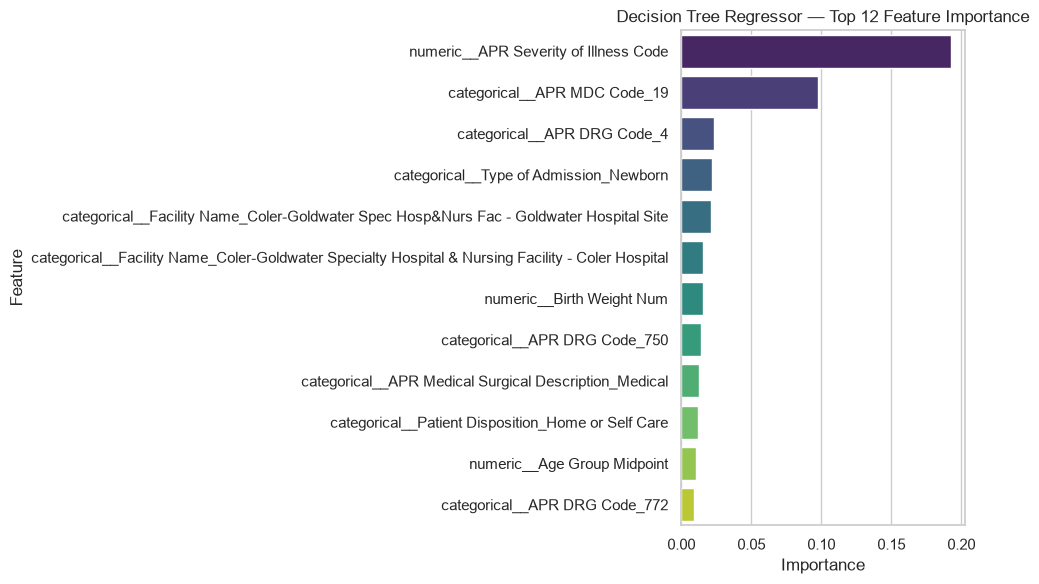

In [23]:
#Decision Tree - Plot

# Top 12 feature importance - Decision Tree
top_n = 12

top_features = (
    feature_importance_dt
    .sort_values(by="Importance", ascending=False)
    .head(top_n)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",      # avoids FutureWarning in newer seaborn
    palette="viridis",
    legend=False
)

plt.title(f"Decision Tree Regressor — Top {top_n} Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [24]:
#Adding to array to compare every model
regression_results.append({
    'Model': 'Decision Tree Regressor',
    'R²': dt_r2,
    'RMSE': dt_rmse,
    'MAE': dt_mae
})

model_registry['Decision Tree Regressor'] = {
    'estimator': dt_model,
    'X_train': X_train_encoded,
    'X_test': X_test,
    'predictions': dt_predictions
}


## Random Forest Regressor

In [25]:
# Random Forest Regressor - Baseline

rf_model = RandomForestRegressor(random_state=42,n_jobs=-1)

rf_model.fit(X_train_encoded, y_train)

rf_r2, rf_rmse, rf_mae, rf_predictions = evaluate_regression_model(
    rf_model,
    X_test_encoded,
    y_test
)

print("Random Forest Regressor — Baseline")
print(f"R²   : {rf_r2:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"MAE  : {rf_mae:.4f}")

# Save baseline results
rf_baseline_r2 = rf_r2
rf_baseline_rmse = rf_rmse
rf_baseline_mae = rf_mae

Random Forest Regressor — Baseline
R²   : 0.4955
RMSE : 12.9801
MAE  : 6.6361


In [26]:
# Random Forest - Feature Importance

feature_importance_rf = pd.DataFrame({
    'Feature': all_feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

print("Random Forest Feature Importance:")
display(feature_importance_rf)

Random Forest Feature Importance:


,Feature,Importance
5,numeric__APR Severity of Illness Code,1.902213e-01
1066,categorical__APR MDC Code_19,9.580166e-02
103,categorical__Facility Name_Coler-Goldwater Spe...,2.050018e-02
902,categorical__APR DRG Code_4,1.820587e-02
3,numeric__Birth Weight Num,1.763366e-02
...,...,...
619,categorical__CCS Procedure Code_123.0,1.160572e-07
618,categorical__CCS Procedure Code_122.0,9.537742e-08
454,categorical__CCS Diagnosis Code_177.0,8.416614e-08
345,categorical__Gender_infrequent_sklearn,4.841171e-08


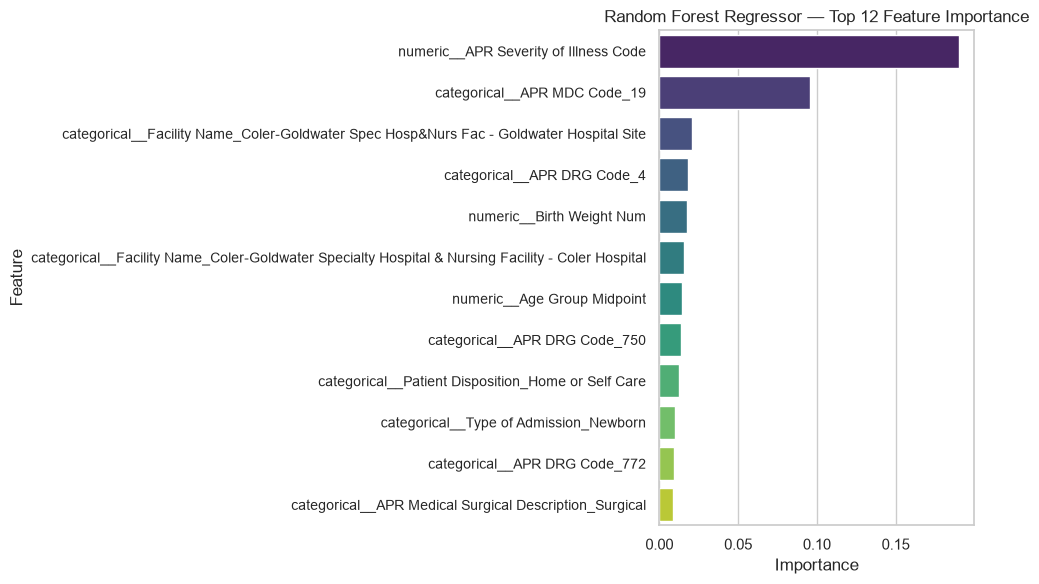

In [27]:
# Random Forest - Top 12 Feature Importance Plot

top_n = 12

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_rf.head(top_n),
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title(f"Random Forest Regressor — Top {top_n} Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [28]:
# Adding Random Forest to regression results

regression_results.append({
    'Model': 'Random Forest Regressor',
    'R²': rf_baseline_r2,
    'RMSE': rf_baseline_rmse,
    'MAE': rf_baseline_mae
})

model_registry['Random Forest Regressor'] = {
    'estimator': rf_model,
    'X_train': X_train_encoded,
    'X_test': X_test,
    'predictions': rf_predictions
}


## Histogram Gradient Boosting Regressor


In [29]:
# Histogram Gradient Boosting Regressor - Baseline

gb_model = HistGradientBoostingRegressor(random_state=42)

gb_model.fit(X_train_encoded.toarray(), y_train)

gb_r2, gb_rmse, gb_mae, gb_predictions = evaluate_regression_model(
    gb_model,
    X_test_encoded.toarray(),
    y_test
)

print("Histogram Gradient Boosting Regressor — Baseline")
print(f"R²   : {gb_r2:.4f}")
print(f"RMSE : {gb_rmse:.4f}")
print(f"MAE  : {gb_mae:.4f}")

# Save baseline results
gb_baseline_r2 = gb_r2
gb_baseline_rmse = gb_rmse
gb_baseline_mae = gb_mae


Histogram Gradient Boosting Regressor — Baseline
R²   : 0.5166
RMSE : 12.7057
MAE  : 6.7583


In [30]:
# Histogram Gradient Boosting - Feature Importance
# HistGradientBoostingRegressor does not expose feature_importances_,
# so permutation importance is used instead.

gb_permutation = permutation_importance(
    gb_model,
    X_test_encoded.toarray()[:1000],
    y_test[:1000],
    n_repeats=3,
    random_state=42,
    scoring='r2',
    n_jobs=2
)

feature_importance_gb = pd.DataFrame({
    'Feature': all_feature_cols,
    'Importance': gb_permutation.importances_mean
}).sort_values(
    by='Importance',
    ascending=False
)

print("Histogram Gradient Boosting Feature Importance (Permutation Importance):")
display(feature_importance_gb)


Histogram Gradient Boosting Feature Importance (Permutation Importance):


,Feature,Importance
5,numeric__APR Severity of Illness Code,0.347737
1066,categorical__APR MDC Code_19,0.164836
1011,categorical__APR DRG Code_750,0.038949
0,numeric__Age Group Midpoint,0.034966
1087,categorical__APR Medical Surgical Description_...,0.033485
...,...,...
347,categorical__Race_Other Race,-0.000712
565,categorical__CCS Diagnosis Code_653.0,-0.000793
549,categorical__CCS Diagnosis Code_5.0,-0.001307
39,categorical__Hospital County_Manhattan,-0.001704


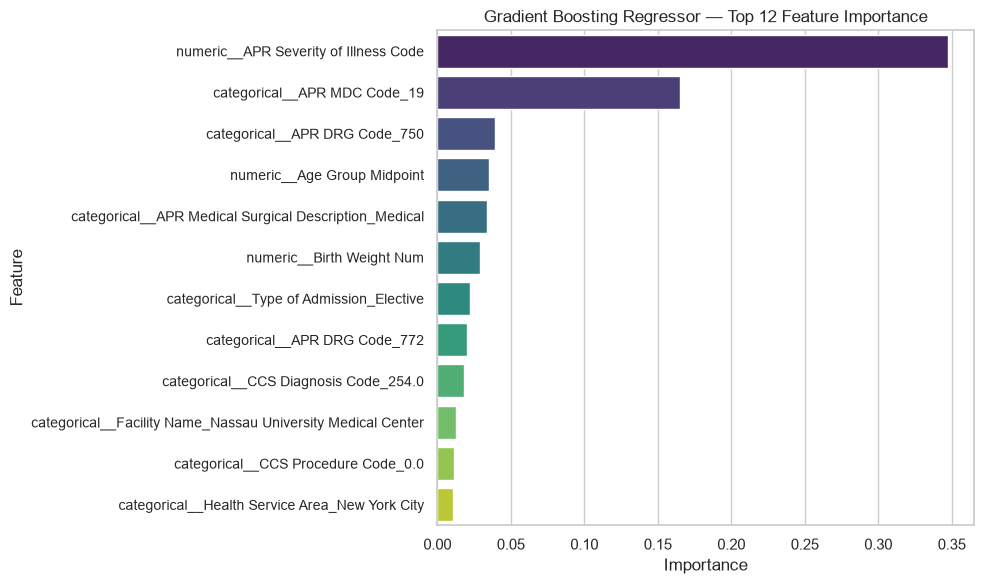

In [31]:
# Gradient Boosting - Top 12 Feature Importance Plot

top_n = 12

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_gb.head(top_n),
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title(f"Gradient Boosting Regressor — Top {top_n} Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [32]:
# Adding Histogram Gradient Boosting to regression results

regression_results.append({
    'Model': 'Histogram Gradient Boosting Regressor',
    'R²': gb_baseline_r2,
    'RMSE': gb_baseline_rmse,
    'MAE': gb_baseline_mae
})

model_registry['Histogram Gradient Boosting Regressor'] = {
    'estimator': gb_model,
    'X_train': X_train,
    'X_test': X_test,
    'predictions': gb_predictions
}


## Support Vector Regression

In [33]:
# Support Vector Regression - Baseline

svr_model = SVR()
scaler = StandardScaler()
y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()

svr_model = SVR(kernel="rbf", C=1.0)

# 1. Fit the model using the sparse encoded features and scaled targets
svr_model.fit(X_train_encoded, y_train_scaled)

# 2. Predict on the test set (output will be scaled)
y_pred_svr_scaled = svr_model.predict(X_test_encoded)

# 3. Reverse the scaling back to original units for proper evaluation
y_pred_svr = scaler.inverse_transform(
    y_pred_svr_scaled.reshape(-1, 1)
).ravel()

# 4. Evaluate using your existing function
svr_r2, svr_rmse, svr_mae, svr_predictions = evaluate_regression_model(
    svr_model, X_test_encoded, y_test
)

print("Support Vector Regression — Baseline")
print(f"R²   : {svr_r2:.4f}")
print(f"RMSE : {svr_rmse:.4f}")
print(f"MAE  : {svr_mae:.4f}")

# Save baseline results
svr_baseline_r2 = svr_r2
svr_baseline_rmse = svr_rmse
svr_baseline_mae = svr_mae

Support Vector Regression — Baseline
R²   : -0.4314
RMSE : 21.8627
MAE  : 12.6362


In [34]:
# Adding SVR to regression results

regression_results.append({
    'Model': 'Support Vector Regression',
    'R²': svr_baseline_r2,
    'RMSE': svr_baseline_rmse,
    'MAE': svr_baseline_mae
})

model_registry['Support Vector Regression'] = {
    'estimator': svr_model,
    'X_train': X_train_encoded,
    'X_test': X_test_encoded,
    'predictions': svr_predictions
}


## K-Nearest Neighbors Regressor

In [35]:
# KNN Regressor - Baseline

knn_model = KNeighborsRegressor()

knn_model.fit(X_train_encoded, y_train)

knn_r2, knn_rmse, knn_mae, knn_predictions = evaluate_regression_model(
    knn_model,
    X_test_encoded,
    y_test
)

print("KNN Regressor — Baseline")
print(f"R²   : {knn_r2:.4f}")
print(f"RMSE : {knn_rmse:.4f}")
print(f"MAE  : {knn_mae:.4f}")

# Save baseline results
knn_baseline_r2 = knn_r2
knn_baseline_rmse = knn_rmse
knn_baseline_mae = knn_mae

KNN Regressor — Baseline
R²   : 0.4031
RMSE : 14.1184
MAE  : 7.6033


In [36]:
# Adding KNN to regression results

regression_results.append({
    'Model': 'KNN Regressor',
    'R²': knn_baseline_r2,
    'RMSE': knn_baseline_rmse,
    'MAE': knn_baseline_mae
})

model_registry['KNN Regressor'] = {
    'estimator': knn_model,
    'X_train': X_train_encoded,
    'X_test': X_test_encoded,
    'predictions': knn_predictions
}


## Viewing all regression results

In [37]:
# Final Regression Results

regression_results_df = pd.DataFrame(regression_results)
regression_results_df = regression_results_df.sort_values(
    by='R²', ascending=False
).reset_index(drop=True)

print("All 10 Regression Models — Ranked by R² (Test Set)")
display(regression_results_df)

best_model_name = regression_results_df.iloc[0]['Model']
second_best_model_name = regression_results_df.iloc[1]['Model']

print(f"\nBest performing model : {best_model_name}")
print(f"Runner-up model       : {second_best_model_name}")


All 10 Regression Models — Ranked by R² (Test Set)


,Model,R²,RMSE,MAE
0,Histogram Gradient Boosting Regressor,0.516564,12.705658,6.758333
1,Random Forest Regressor,0.495451,12.980141,6.636124
2,Ridge Regression,0.492721,13.015205,7.458967
3,Linear Regression,0.490895,13.038614,7.472849
4,Polynomial Regression,0.441025,13.662304,7.905302
5,KNN Regressor,0.403084,14.118353,7.603293
6,Lasso Regression,0.388499,14.289798,8.352676
7,ElasticNet Regression,0.352384,14.705727,8.672243
8,Decision Tree Regressor,0.084865,17.481157,8.682167
9,Support Vector Regression,-0.431374,21.862719,12.636182



Best performing model : Histogram Gradient Boosting Regressor
Runner-up model       : Random Forest Regressor


## 5-Fold Cross-Validated R² — Two Best Baseline Models

No hyperparameter tuning is performed in this notebook. After all 10 baseline models are evaluated on the same held-out test set, the two models with the highest test-set R² are selected for 5-fold cross-validation on the training data.

The held-out test set is not used during cross-validation.

In [38]:
from sklearn.model_selection import cross_val_score
import pandas as pd

# Select the two best baseline models based on test-set R².
top_two = regression_results_df.head(2)['Model'].tolist()

print("Two best baseline models selected for 5-fold CV:")
print("1.", top_two[0])
print("2.", top_two[1])

cv_results = []

for model_name in top_two:
    info = model_registry[model_name]
    estimator = info['estimator']
    X_cv = X_train_encoded.toarray()
    y_cv = y_train

    cv_scores = cross_val_score(
        estimator,
        X_cv,
        y_cv,
        cv=5,
        scoring='r2',
        n_jobs=2
    )

    cv_results.append({
        'Model': model_name,
        '5-Fold CV R² Mean': cv_scores.mean(),
        '5-Fold CV R² Std': cv_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df)


Two best baseline models selected for 5-fold CV:
1. Histogram Gradient Boosting Regressor
2. Random Forest Regressor


,Model,5-Fold CV R² Mean,5-Fold CV R² Std
0,Histogram Gradient Boosting Regressor,0.515143,0.019175
1,Random Forest Regressor,0.472447,0.027604


## Final Regression Comparison

The final comparison contains the 10 baseline regression models evaluated on the same held-out test set using R², RMSE, and MAE. The two best baseline models are additionally reported with their 5-fold cross-validated R².

## Best Model — Residual & Predicted-vs-Actual Plots

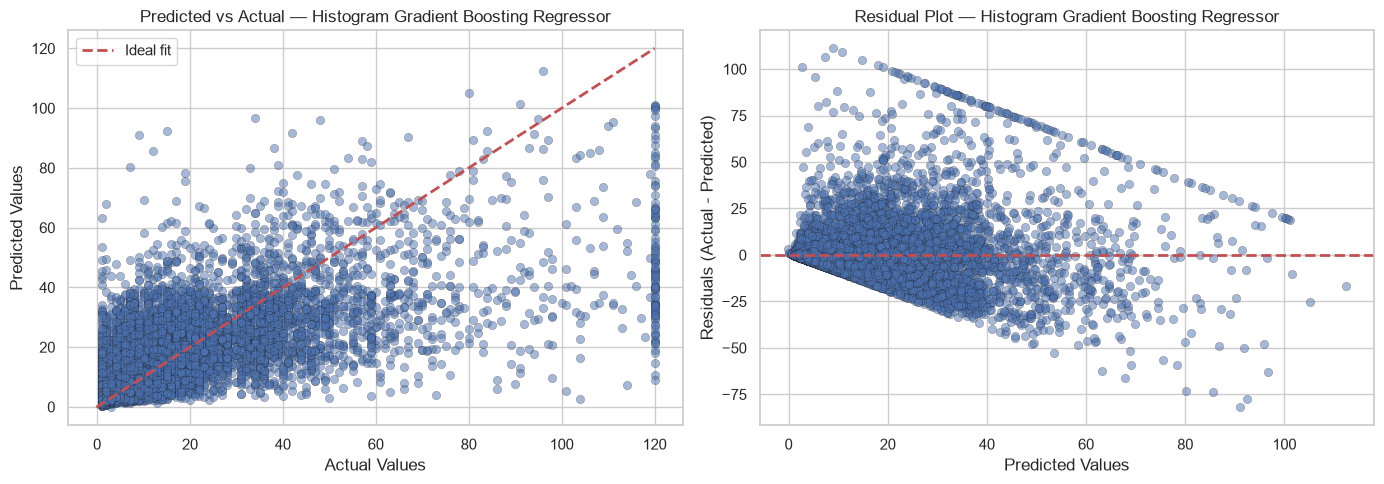

Residual mean : -0.0453
Residual std  : 12.7060


In [39]:
# Residual plot and Predicted-vs-Actual plot for the best model

best_info = model_registry[best_model_name]
best_y_pred = best_info['predictions']
best_residuals = y_test - best_y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, best_y_pred, alpha=0.5, edgecolor='k', linewidth=0.3)
min_val = min(y_test.min(), best_y_pred.min())
max_val = max(y_test.max(), best_y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal fit')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title(f'Predicted vs Actual — {best_model_name}')
axes[0].legend()

# Residual plot
axes[1].scatter(best_y_pred, best_residuals, alpha=0.5, edgecolor='k', linewidth=0.3)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title(f'Residual Plot — {best_model_name}')

plt.tight_layout()
plt.show()

print(f"Residual mean : {best_residuals.mean():.4f}")
print(f"Residual std  : {best_residuals.std():.4f}")
